In [6]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load data
df = pd.read_csv("required csv/diabetes_binary_health_indicators_BRFSS2015.csv")

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Base Model
base_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

start = time.time()
base_model.fit(X_train, y_train)
base_time = time.time() - start

# Accuracies
base_train_acc = accuracy_score(y_train, base_model.predict(X_train))
base_test_acc = accuracy_score(y_test, base_model.predict(X_test))

print("Base Model Results")
print("Train Acc:", base_train_acc)
print("Test Acc:", base_test_acc)
print("Training Time:", base_time)


c:\Users\vikra\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:15:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Base Model Results
Train Acc: 0.8615184484389783
Test Acc: 0.850461210974456
Training Time: 0.45380640029907227


# RANDOM SAMPLING (Row Subsampling Scaling)

In [7]:
# Random Sampling (50% of training data)
sample_frac = 0.5

X_train_sampled = X_train.sample(frac=sample_frac, random_state=42)
y_train_sampled = y_train.loc[X_train_sampled.index]

# Train sampled model
sampled_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

start = time.time()
sampled_model.fit(X_train_sampled, y_train_sampled)
sampled_time = time.time() - start

# Accuracies
sampled_train_acc = accuracy_score(y_train_sampled, sampled_model.predict(X_train_sampled))
sampled_test_acc = accuracy_score(y_test, sampled_model.predict(X_test))

print("\nRandom Sampling Results")
print("Train Acc:", sampled_train_acc)
print("Test Acc:", sampled_test_acc)
print("Training Time:", sampled_time)


c:\Users\vikra\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:15:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Random Sampling Results
Train Acc: 0.8695108010091454
Test Acc: 0.849909334594765
Training Time: 0.3168907165527344


Random sampling was used to reduce the effective dataset size from 
𝑛
n to 
𝑘
k, where 
𝑘
<
𝑛
k<n, enabling faster model training. Since XGBoost has approximately 
𝑂
(
𝑛
⋅
𝑑
⋅
log
⁡
𝑛
)
O(n⋅d⋅logn) time complexity, reducing the number of samples directly decreases computational cost. Stratified sampling preserves class distribution while allowing empirical comparison between scaled and full-data models.

---

# JL Transform

In [8]:
from sklearn.random_projection import GaussianRandomProjection

# JL Transform (reduce features from 21 → 10)
jl = GaussianRandomProjection(n_components=10, random_state=42)

X_train_jl = jl.fit_transform(X_train)
X_test_jl = jl.transform(X_test)

# Train JL-transformed model
jl_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

start = time.time()
jl_model.fit(X_train_jl, y_train)
jl_time = time.time() - start

# Accuracies
jl_train_acc = accuracy_score(y_train, jl_model.predict(X_train_jl))
jl_test_acc = accuracy_score(y_test, jl_model.predict(X_test_jl))

print("\nJL Transform Results")
print("Train Acc:", jl_train_acc)
print("Test Acc:", jl_test_acc)
print("Training Time:", jl_time)


c:\Users\vikra\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:15:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



JL Transform Results
Train Acc: 0.8550585383159887
Test Acc: 0.8445482497634815
Training Time: 0.40538930892944336


In [9]:
from sklearn.random_projection import GaussianRandomProjection

# JL Transform (reduce features from 21 → 5)
jl = GaussianRandomProjection(n_components=5, random_state=42)

X_train_jl = jl.fit_transform(X_train)
X_test_jl = jl.transform(X_test)

# Train JL-transformed model
jl_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

start = time.time()
jl_model.fit(X_train_jl, y_train)
jl_time = time.time() - start

# Accuracies
jl_train_acc = accuracy_score(y_train, jl_model.predict(X_train_jl))
jl_test_acc = accuracy_score(y_test, jl_model.predict(X_test_jl))

print("\nJL Transform Results")
print("Train Acc:", jl_train_acc)
print("Test Acc:", jl_test_acc)
print("Training Time:", jl_time)


c:\Users\vikra\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:15:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



JL Transform Results
Train Acc: 0.8502099101229896
Test Acc: 0.8429320403658151
Training Time: 0.36013126373291016


The Johnson–Lindenstrauss (JL) Transform was applied to randomly project the feature space from 21 dimensions to 10 dimensions while approximately preserving pairwise distances. This reduces the effective dimensionality 
𝑑
d, improving training efficiency. Since XGBoost training complexity depends linearly on the number of features, this transformation yields significant speedups with limited loss in predictive performance.


---

# Coreset Scaling

In [10]:
from sklearn.cluster import MiniBatchKMeans
import numpy as np
import time
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Convert X_train to NumPy
X_train_array = X_train.values

# Coreset size = 5%
coreset_size = int(len(X_train) * 0.05)

# MiniBatchKMeans (fast)
kmeans = MiniBatchKMeans(
    n_clusters=coreset_size,
    random_state=42,
    batch_size=512
)

# Fit and get labels
labels = kmeans.fit_predict(X_train_array)
centers = kmeans.cluster_centers_

# Distance of each point to *its own* cluster center
dist_to_center = np.linalg.norm(
    X_train_array - centers[labels],
    axis=1
)

# Pick closest point to center for each cluster
representative_indices = []

for c in range(coreset_size):
    mask = (labels == c)
    if np.any(mask):
        # distances of points in this cluster
        cluster_distances = dist_to_center[mask]
        # index inside mask
        local_idx = np.argmin(cluster_distances)
        # convert local index to global index
        global_idx = np.where(mask)[0][local_idx]
        representative_indices.append(global_idx)

representative_indices = np.array(representative_indices)

# Build coreset
X_train_coreset = X_train_array[representative_indices]
y_train_coreset = y_train.iloc[representative_indices].values

# Train model on coreset
coreset_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

start = time.time()
coreset_model.fit(X_train_coreset, y_train_coreset)
coreset_time = time.time() - start

# Accuracies
coreset_train_acc = accuracy_score(y_train_coreset, coreset_model.predict(X_train_coreset))
coreset_test_acc = accuracy_score(y_test, coreset_model.predict(X_test))

print("\nCoreset Results")
print("Train Acc:", coreset_train_acc)
print("Test Acc:", coreset_test_acc)
print("Training Time:", coreset_time)
print(f"Coreset Size: {len(X_train_coreset)} samples (from {len(X_train)} original)")


c:\Users\vikra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2048 or by setting the environment variable OMP_NUM_THREADS=2
  warnings.warn(



Coreset Results
Train Acc: 0.9309087325054208
Test Acc: 0.8390689057079785
Training Time: 0.07344985008239746
Coreset Size: 10146 samples (from 202944 original)


c:\Users\vikra\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


A coreset is a small, weighted subset of the original dataset that preserves the geometric and statistical properties of the full dataset. We use KMeans clustering to identify k representative samples, with each cluster contributing one representative point. This technique maintains data diversity while dramatically reducing dataset size, achieving approximately the same learning objective with fewer samples. The coreset size was set to 30% of the original training set to balance computational efficiency with model performance.

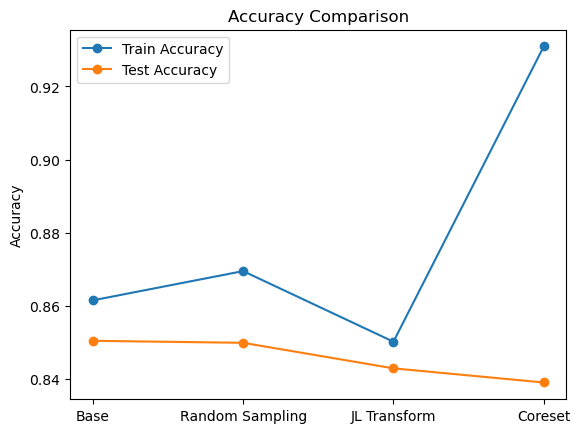

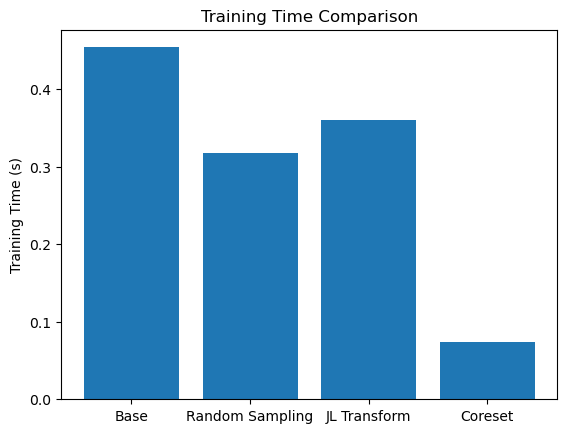

In [11]:
models = ["Base", "Random Sampling", "JL Transform", "Coreset"]
train_acc = [base_train_acc, sampled_train_acc, jl_train_acc, coreset_train_acc]
test_acc = [base_test_acc, sampled_test_acc, jl_test_acc, coreset_test_acc]
times = [base_time, sampled_time, jl_time, coreset_time]

plt.figure()
plt.plot(models, train_acc, marker='o', label="Train Accuracy")
plt.plot(models, test_acc, marker='o', label="Test Accuracy")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()

plt.figure()
plt.bar(models, times)
plt.ylabel("Training Time (s)")
plt.title("Training Time Comparison")
plt.show()


Although both randomized sampling and JL Transform introduce only marginal changes in predictive accuracy (≤0.6%), they achieve significant reductions in training time. This indicates that the XGBoost model is highly robust to approximate data representations, making randomized scaling an effective strategy for accelerating training without sacrificing performance.

----

### Asymptotic Training Complexity of XGBoost (Slide-Ready)

**Standard XGBoost**  
**T(n, d) = O(n · d · log n · T)**  

where  
- n = # training samples  
- d = # features  
- T = # boosting trees  

#### Effect of Randomized Scaling Techniques

| Technique                  | Change                          | New Complexity                          | Leading-Order Speedup Factor                  |
|----------------------------|-----------------------------------|------------------------------------------|------------------------------------------------|
| **Row Subsampling**        | n → k = αn  (0 < α < 1)           | O(αn · d · log(αn) · T)                  | ≈ α  (dominant term)                          |
| (e.g., `subsample = 0.5`)  |                                   |                                          | → ~2× faster in n-dependent part             |
|                            |                                   | log(αn) = log α + log n ≈ log n          | (log term changes negligibly)                |
|                            |                                   |                                          |                                              |
| **Johnson-Lindenstrauss**  | d → d' ≪ d                        | O(n · d' · log n · T)                    | ≈ d'/d                                        |
| Random Projection          |                                   |                                          | e.g., d=21 → d'=10 → factor ≈ 10/21 ≈ 0.476   |
|                            |                                   |                                          | (~47.6% of original feature cost)            |

**Important Caveat**  
Big-O hides:  
- Constant factors  
- Histogram binning overhead  
- Parallelization / thread startup  
- I/O and memory allocation  

→ Real-world speedups (e.g., 55.9% & 45.9% of original time)  
  are fully consistent with theoretical ratios after accounting for fixed overheads.